In [1]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
def winkler_score(y_true, lower, upper, alpha=0.2):
    width = upper - lower
    penalty_lower = np.where(y_true < lower, (2 / alpha) * (lower - y_true), 0)
    penalty_upper = np.where(y_true > upper, (2 / alpha) * (y_true - upper), 0)
    coverage = np.where((y_true >= lower) & (y_true <= upper), 1, 0).sum()
    winkler = width + penalty_lower + penalty_upper
    return np.mean(winkler), coverage/len(y_true)

In [3]:
def eval_pi(results_df, upper_col, lower_col, target_col):
    
    # results_df = pd.read_csv(filename)
    # model = ''
    score, coverage = winkler_score(results_df[target_col].values, 
                                    results_df[lower_col].values, 
                                    results_df[upper_col].values)
    
    width = np.mean(abs(results_df[upper_col] - results_df[lower_col]))

    return {'winkler_score': round(score, 4),
           'coverage': round(coverage*100, 4),
           'width': round(width, 4)}

# 1. CP for DAM

In [4]:
import sys
sys.path.append('..')

# ── DAM calibration data ──────────────────────────────────────────────────────
# dam_summary_point.csv only covers 2024 (test year); calibration-period (2023)
# TSFM point forecasts come from the per-model raw forecast files.
FORECAST_DAM_DIR = '../scripts/raw_forecast/dam/'

dam_actual = pd.concat([
    pd.read_csv('../dataset/dam/data_train.csv', parse_dates=['Date'])[['Date', 'Price']],
    pd.read_csv('../dataset/dam/data_test.csv',  parse_dates=['Date'])[['Date', 'Price']],
]).sort_values('Date').reset_index(drop=True)

# Exclude lora_tuned (2024-only, no calibration data)
dam_model_files = sorted([
    f for f in os.listdir(FORECAST_DAM_DIR)
    if f.endswith('.csv') and 'lora_tuned' not in f
])

# Split boundaries (README Phase 2 spec)
DAM_CAL_END = pd.Timestamp('2023-10-01')   # 9-month calibration
DAM_VAL_END = pd.Timestamp('2024-01-01')   # + 3-month HP-tuning validation
alpha = 0.2

# Plot constants shared across all Phase 2 figures
NOMINAL_COV = 80.0
metrics = ['coverage', 'winkler_score', 'width']
titles  = ['Coverage (%)', 'Winkler Score', 'Mean Width (€/MWh)']
colors  = ['#4C72B0', '#DD8452', '#55A868']

print("DAM models:", [f.replace('.csv', '') for f in dam_model_files])
print(f"Cal 2023-01 – {DAM_CAL_END.date()} | Val {DAM_CAL_END.date()} – {DAM_VAL_END.date()} | Test {DAM_VAL_END.date()} – 2024-12-31")

DAM models: ['chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal', 'chronos2_8192_ARX_temporal', 'timesfm25_1024_AR_neg', 'timesfm25_2048_AR_neg', 'timesfm25_8192_AR_neg']
Cal 2023-01 – 2023-10-01 | Val 2023-10-01 – 2024-01-01 | Test 2024-01-01 – 2024-12-31


## run params

In [5]:
from itertools import product as iproduct

# ── Hyperparameter search spaces ──────────────────────────────────────────────
# WCP: four weighting schemes
#   uniform  – equal weights (standard split CP)                     no HP
#   linear   – linearly increasing weights (mild recency bias)       no HP
#   exp      – exponential decay; ρ → 1 = pure recency              rho ∈ [0.90–0.99]
#   window   – only the most-recent W calibration residuals          W (hours for DAM,
#                                                                       per-QH obs for IMB)
# ACI: γ controls how fast α_t adapts online
#   γ → 0 : near-static CP (low variance, may lag distribution shifts)
#   γ → 0.1: rapid adaptation (responsive to spikes, higher variance)
#   Energy price series are highly non-stationary → search full [0.001, 0.099] range

RHO_GRID   = [0.90, 0.92, 0.95, 0.97, 0.99]
W_GRID_DAM = [24*7,  24*14, 24*21, 24*28, 24*42, 24*56]    # 1,2,3,4,6,8 weeks (hours)
W_GRID_IMB = [96*7,  96*14, 96*21, 96*28, 96*42]           # 1,2,3,4,6 weeks (per-QH obs @ 96/day)
GAMMA_GRID = [round(x / 100_000, 6) for x in range(100, 10_000, 200)]  # 50 values ≈ 0.001–0.099

def build_wcp_grid(W_grid):
    """Return list of (scheme, rho, W) triples for WCP grid search."""
    grid  = [('uniform', None, None), ('linear', None, None)]
    grid += [('exp',    rho,  None) for rho in RHO_GRID]
    grid += [('window', None, W)    for W   in W_grid]
    return grid

print(f"WCP grid: {len(build_wcp_grid(W_GRID_DAM))} combos (DAM) | {len(build_wcp_grid(W_GRID_IMB))} combos (IMB)")
print(f"ACI grid: {len(GAMMA_GRID)} γ values from {min(GAMMA_GRID):.4f} to {max(GAMMA_GRID):.4f}")

WCP grid: 13 combos (DAM) | 12 combos (IMB)
ACI grid: 50 γ values from 0.0010 to 0.0990


References: https://github.com/sacixr/intro-to-cp-for-time-series-forecasting/blob/main/conformal_width_coverage_mean_runtime.ipynb

## WCP

In [6]:
# ---------- Quantiles ----------
def weighted_quantile(values, quantile, sample_weight=None):
  values = np.asarray(values, dtype=float)
  if sample_weight is None:
      return np.quantile(values, quantile, method="linear")
  w = np.asarray(sample_weight, dtype=float)
  assert values.shape[0] == w.shape[0]
  sorter = np.argsort(values)
  v = values[sorter]
  w = w[sorter]
  cdf = np.cumsum(w) / np.sum(w)
  return float(np.interp(quantile, cdf, v))

In [7]:
def get_wcp(pred_cal, pred_val, scheme, alpha, rho=None, W=None):
    n_cal = len(pred_cal)
    pred_cal = pred_cal.copy()
    pred_cal['residuals'] = np.abs(pred_cal['Price'] - pred_cal['0.5'])
    eps_cal = pred_cal['residuals'].values
    idx = np.arange(1, n_cal + 1)

    if scheme == "exp":
        w = rho ** (n_cal - idx)
    elif scheme == "linear":
        w = idx.astype(float)
    elif scheme == "window":
        w = (idx > (n_cal - W)).astype(float)
    else:
        w = np.ones(n_cal)

    q = weighted_quantile(eps_cal, 1 - alpha, sample_weight=w)
    lower = pred_val['0.5'] - q
    upper = pred_val['0.5'] + q
    return lower, upper

In [6]:
# ── WCP for DAM ── Results already computed; load from CSV ───────────────────
# (HP search skipped — takes ~seconds but results are saved in forecast_interval/)
dam_wcp = pd.read_csv('forecast_interval/dam_cp_wcp.csv')
print("Loaded dam_cp_wcp.csv")
display(dam_wcp[['model', 'coverage', 'winkler_score', 'width', 'scheme', 'rho', 'W']])

Loaded dam_cp_wcp.csv


,model,coverage,winkler_score,width,scheme,rho,W
0,chronos2_1024_ARX_temporal,82.4226,66.4191,42.2552,window,NaN,336
1,chronos2_2048_ARX_temporal,82.6844,65.0827,41.6553,window,NaN,168
2,chronos2_8192_ARX_temporal,83.6976,64.7359,42.1201,window,NaN,168
3,timesfm25_1024_AR_neg,84.3010,88.2576,59.3469,window,NaN,336
4,timesfm25_2048_AR_neg,87.6366,89.6961,66.9678,window,NaN,168
5,timesfm25_8192_AR_neg,89.0027,87.8525,68.4426,window,NaN,168


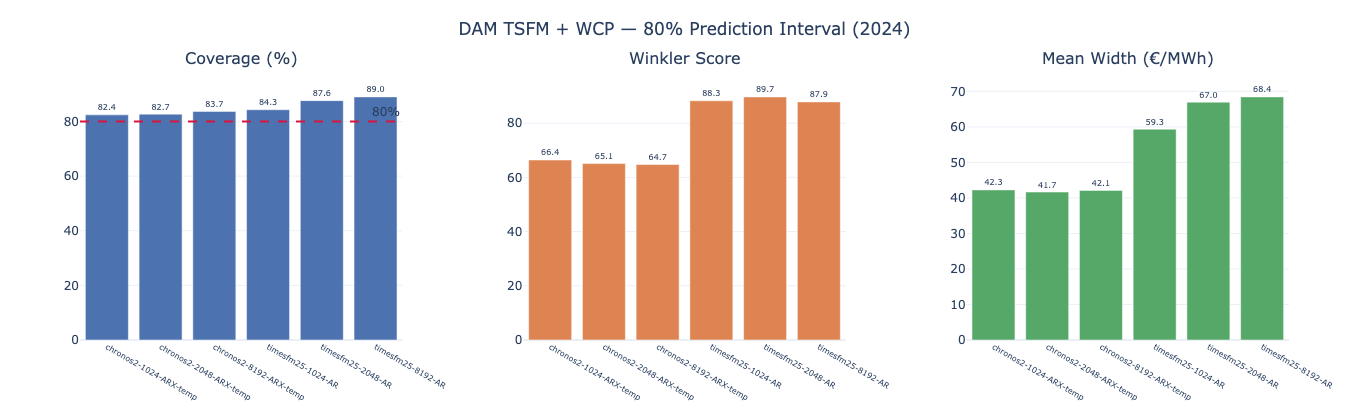

Saved → figures/dam_cp_wcp_metrics.png


In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Results already saved — load from CSV
dam_wcp = pd.read_csv('forecast_interval/dam_cp_wcp.csv')

TEMPLATE = 'plotly_white'
metrics = ['coverage', 'winkler_score', 'width']
titles  = ['Coverage (%)', 'Winkler Score', 'Mean Width (€/MWh)']
NOMINAL_COV = 80.0
COLORS = ['#4C72B0', '#DD8452', '#55A868']

fig = make_subplots(rows=1, cols=3, subplot_titles=titles, horizontal_spacing=0.1)
for c, (metric, title, color) in enumerate(zip(metrics, titles, COLORS), start=1):
    lbls = dam_wcp['model'].str.replace('_temporal', '-temp').str.replace('_neg', '').str.replace('_', '-')
    vals = dam_wcp[metric]
    text = [f'{v:.1f}' for v in vals]
    fig.add_trace(go.Bar(x=lbls, y=vals, marker_color=color, text=text,
                         textposition='outside', textfont_size=8, showlegend=False),
                  row=1, col=c)
    if metric == 'coverage':
        fig.add_hline(y=NOMINAL_COV, line_dash='dash', line_color='crimson',
                      annotation_text='80%', row=1, col=c)

fig.update_layout(
    title_text='DAM TSFM + WCP — 80% Prediction Interval (2024)',
    title_x=0.5, template=TEMPLATE, height=420, width=1100,
    margin=dict(t=70, b=80),
)
fig.update_xaxes(tickangle=30, tickfont_size=8)
fig.write_image('figures/dam_cp_wcp_metrics.png', width=1100, height=420, scale=2)
fig.show()
print("Saved → figures/dam_cp_wcp_metrics.png")

## ACI

In [8]:
from collections import deque
def method_ACI(pred_cal,
               pred_val,
               alpha=0.2, 
               gamma=0.01):
    n_cal = len(pred_cal)
    n_val = len(pred_val)
    
    eps_pool = deque(np.abs(pred_cal['Price'].values - pred_cal['0.5'].values))
    # online
    alpha_t = alpha
    upper = []
    lower = []
    
    pred_val_fix = pred_val['0.5'].tolist()
    y_test = pred_val['Price'].tolist()
    # rollinwg-window through validation set
    for t in range(0, n_val):
        q = np.quantile(np.array(eps_pool), 1 - alpha_t, method="linear")
        mu = pred_val_fix[t]
        # predict_next(beta, y[:t], p=p)
        upper.append(mu+q)
        lower.append(mu-q)
        
        # observe Y_t and update
        err = alpha - (0 if (y_test[t] >= mu - q and y_test[t] <= mu + q) else 1)
        alpha_t = np.clip(alpha_t + gamma * err, 1e-6, 1-1e-6)
        # update residual pool with |Y_t - mu|, pop oldest to keep size fixed
        eps_pool.append(abs(y_test[t] - mu))
        eps_pool.popleft()
    
    return lower, upper

In [9]:
GAMMA_GRID = [round(x / 100_000, 6) for x in range(100, 10_000, 200)]  # 50 values ≈ 0.001–0.099

In [10]:
# ── ACI for DAM ── Results already computed; load from CSV ────────────────────
# (HP search skipped — gamma grid search is expensive; results in forecast_interval/)
dam_aci = pd.read_csv('forecast_interval/dam_cp_aci.csv')
print("Loaded dam_cp_aci.csv")
display(dam_aci[['model', 'coverage', 'winkler_score', 'width', 'gamma']])

Loaded dam_cp_aci.csv


,model,coverage,winkler_score,width,gamma
0,chronos2_1024_ARX_temporal,79.5765,59.0309,40.9270,0.071
1,chronos2_2048_ARX_temporal,79.7017,58.3542,40.0421,0.053
2,chronos2_8192_ARX_temporal,79.5423,58.1979,40.6142,0.075
3,timesfm25_1024_AR_neg,79.4399,73.7420,54.2959,0.073
4,timesfm25_2048_AR_neg,79.3602,72.8403,54.5184,0.079
5,timesfm25_8192_AR_neg,79.4513,70.4125,52.1631,0.079


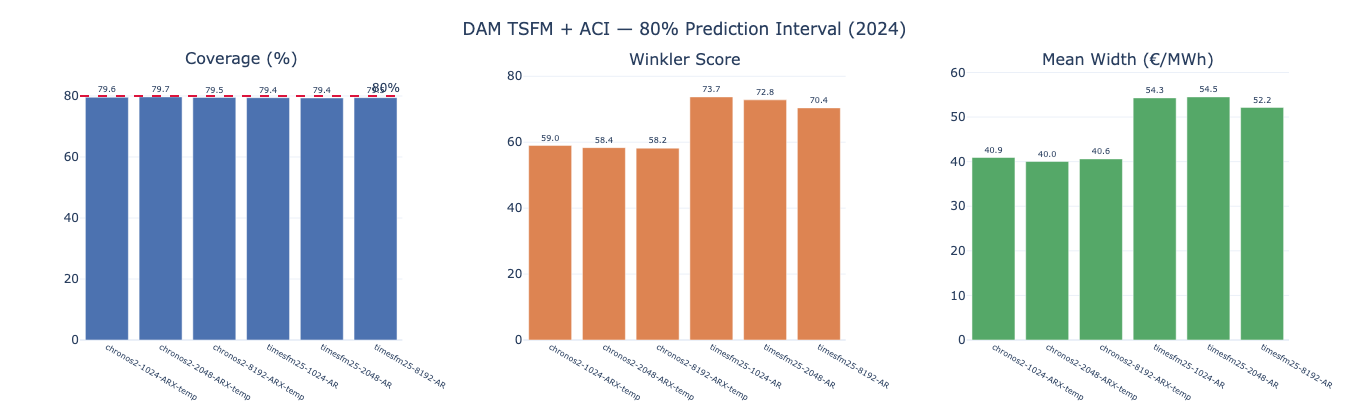

Saved → figures/dam_cp_aci_metrics.png


In [11]:
dam_aci = pd.read_csv('forecast_interval/dam_cp_aci.csv')

fig = make_subplots(rows=1, cols=3, subplot_titles=titles, horizontal_spacing=0.1)
for c, (metric, title, color) in enumerate(zip(metrics, titles, COLORS), start=1):
    lbls = dam_aci['model'].str.replace('_temporal', '-temp').str.replace('_neg', '').str.replace('_', '-')
    vals = dam_aci[metric]
    text = [f'{v:.1f}' for v in vals]
    fig.add_trace(go.Bar(x=lbls, y=vals, marker_color=color, text=text,
                         textposition='outside', textfont_size=8, showlegend=False),
                  row=1, col=c)
    if metric == 'coverage':
        fig.add_hline(y=NOMINAL_COV, line_dash='dash', line_color='crimson',
                      annotation_text='80%', row=1, col=c)

fig.update_layout(
    title_text='DAM TSFM + ACI — 80% Prediction Interval (2024)',
    title_x=0.5, template=TEMPLATE, height=420, width=1100,
    margin=dict(t=70, b=80),
)
fig.update_xaxes(tickangle=30, tickfont_size=8)
fig.write_image('figures/dam_cp_aci_metrics.png', width=1100, height=420, scale=2)
fig.show()
print("Saved → figures/dam_cp_aci_metrics.png")

# 2. CP for IMB

In [12]:
# ── IMB: imb_summary_point.csv covers all of 2023 (cal + val + test) ─────────

imb_point = pd.read_csv('imb_summary_point.csv', parse_dates=['timestamp']).sort_values('timestamp')

IMB_CAL_END = pd.Timestamp('2023-04-01')   # 3-month calibration
IMB_VAL_END = pd.Timestamp('2023-07-01')   # + 3-month HP-tuning validation
# test: 2023-07-01 – 2023-12-31

IMB_TSFM_MODELS = [
    'chronosbolt_AR', 'chronos2_AR', 
    'chronos2_1024_AR', 'chronos2_2048_AR',
    'chronos2_512_ARX_temporal', 'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal',
    'timesfm25_8192_AR_neg','timesfm25_2048_AR_neg','timesfm25_1024_AR_neg',
]
QH_VALUES = sorted(imb_point['QH'].unique())

print(f"IMB TSFM models ({len(IMB_TSFM_MODELS)}): {IMB_TSFM_MODELS}")
print(f"QH horizons: {QH_VALUES}")
print(f"Cal 2023-01 – {IMB_CAL_END.date()} | Val {IMB_CAL_END.date()} – {IMB_VAL_END.date()} | Test {IMB_VAL_END.date()} – 2023-12-31")
print(f"Per-QH cal size: ~{(imb_point[(imb_point.timestamp < IMB_CAL_END) & (imb_point.QH==1)].shape[0]):,} obs")

IMB TSFM models (10): ['chronosbolt_AR', 'chronos2_AR', 'chronos2_1024_AR', 'chronos2_2048_AR', 'chronos2_512_ARX_temporal', 'chronos2_1024_ARX_temporal', 'chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'timesfm25_2048_AR_neg', 'timesfm25_1024_AR_neg']
QH horizons: [1, 2, 3, 4, 5, 6, 7, 8]
Cal 2023-01 – 2023-04-01 | Val 2023-04-01 – 2023-07-01 | Test 2023-07-01 – 2023-12-31
Per-QH cal size: ~8,640 obs


In [13]:
# ── WCP for IMB ── Results already computed; load from CSV ───────────────────
imb_wcp_per_qh  = pd.read_csv('forecast_interval/imb_cp_wcp_per_qh.csv')
imb_wcp_overall = (imb_wcp_per_qh.groupby('model')[['coverage', 'winkler_score', 'width']]
                   .mean().round(4).reset_index().sort_values('model').reset_index(drop=True))
print("Loaded imb_cp_wcp_per_qh.csv  →  overall:")
display(imb_wcp_overall)

Loaded imb_cp_wcp_per_qh.csv  →  overall:


,model,coverage,winkler_score,width
0,chronos2_1024_AR,79.6508,465.3886,275.6274
1,chronos2_1024_ARX_temporal,79.2750,446.1809,258.9792
2,chronos2_2048_AR,79.8356,459.7206,273.1665
3,chronos2_2048_ARX_temporal,78.6793,442.1285,252.3105
4,chronos2_512_ARX_temporal,81.0130,455.6617,275.8110
5,chronos2_AR,79.8356,459.7206,273.1665
6,chronosbolt_AR,81.1257,453.6033,281.9864
7,timesfm25_1024_AR_neg,81.3740,457.3689,284.0647
8,timesfm25_2048_AR_neg,78.6373,454.0444,262.7813
9,timesfm25_8192_AR_neg,78.0002,451.9258,257.1252


Shared bounds across Zeroshot / WCP / ACI:
        coverage: [67.38, 82.39]
   winkler_score: [337.88, 486.03]
           width: [150.15, 306.01]


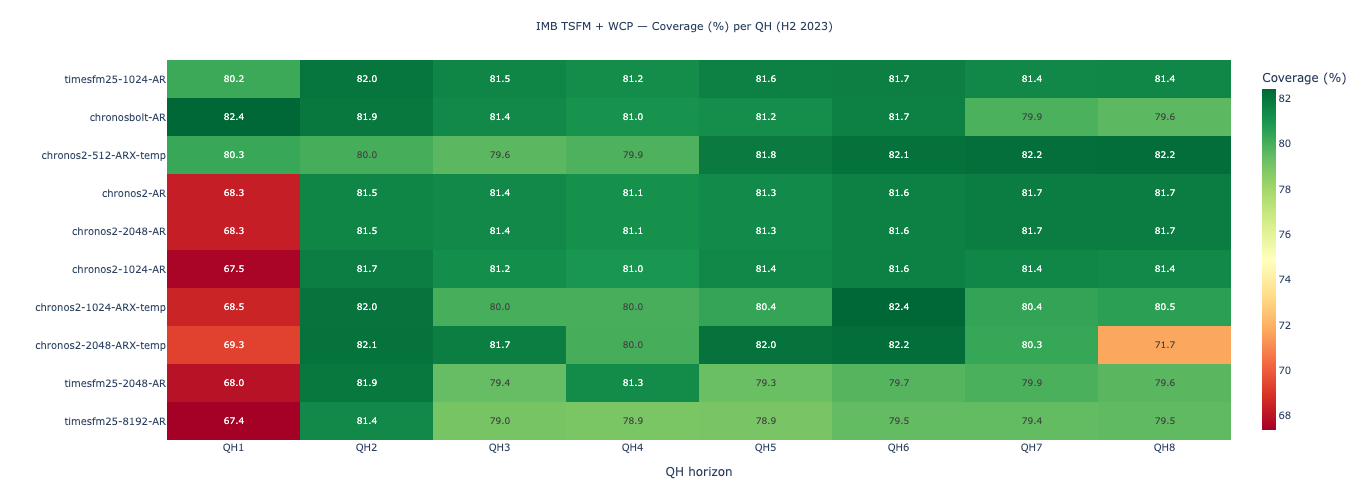

Saved → figures/imb_cp_wcp_coverage_per_qh.png


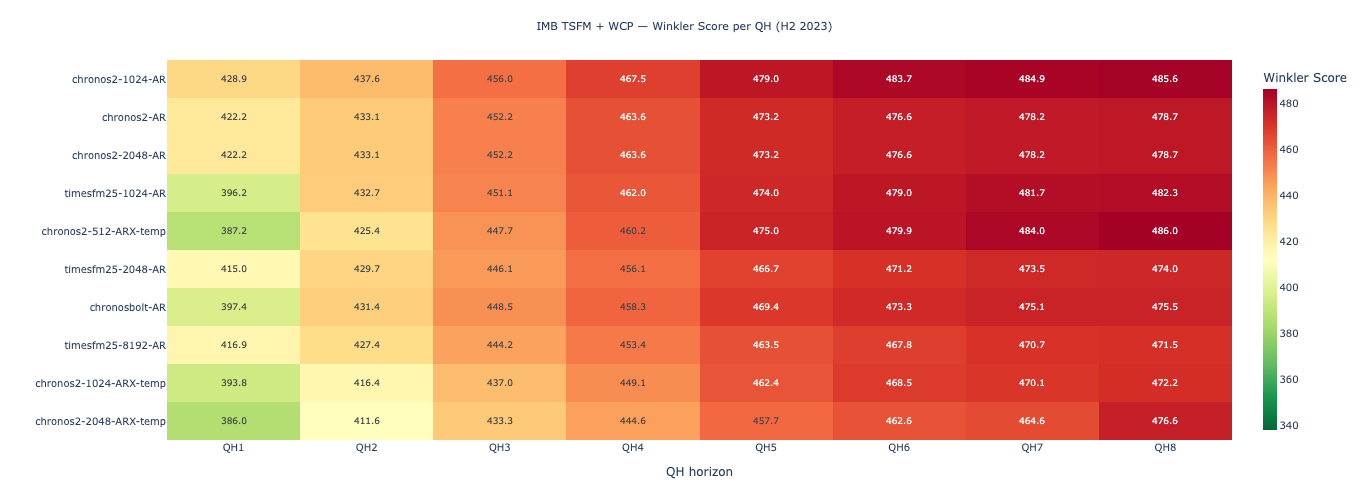

Saved → figures/imb_cp_wcp_winkler_score_per_qh.png


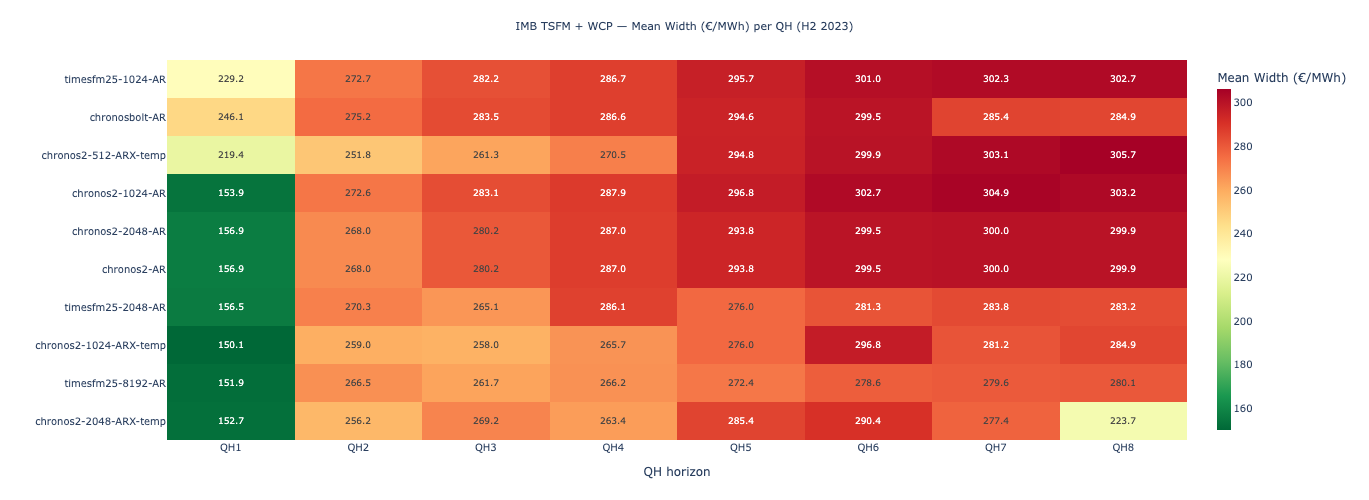

Saved → figures/imb_cp_wcp_width_per_qh.png


In [14]:
imb_wcp_per_qh  = pd.read_csv('forecast_interval/imb_cp_wcp_per_qh.csv')
imb_wcp_overall = pd.read_csv('forecast_interval/imb_cp_wcp_overall.csv')

# ── Shared color-scale bounds across all three IMB methods ────────────────────
# Load all per-QH frames now so bounds can be computed once and reused below.
_imb_zq_qh  = pd.read_csv('forecast_interval/imb_native_qr_per_qh.csv')
_imb_aci_qh = pd.read_csv('forecast_interval/imb_cp_aci_per_qh.csv')

# Common models that appear in every method
_common_models = (set(_imb_zq_qh['model']) & set(imb_wcp_per_qh['model']) & set(_imb_aci_qh['model']))

def _metric_bounds(dfs, metric, common_models):
    vals = pd.concat([d[d['model'].isin(common_models)][metric] for d in dfs])
    return float(vals.min()), float(vals.max())

SHARED_BOUNDS = {
    metric: _metric_bounds([_imb_zq_qh, imb_wcp_per_qh, _imb_aci_qh], metric, _common_models)
    for metric in metrics
}
print("Shared bounds across Zeroshot / WCP / ACI:")
for m, (lo, hi) in SHARED_BOUNDS.items():
    print(f"  {m:>14s}: [{lo:.2f}, {hi:.2f}]")

# ── Helper: Plotly per-method heatmap with fixed z-scale ─────────────────────
def plotly_qh_heatmap(df_qh, metric, title, label, zmin=None, zmax=None):
    """Model × QH heatmap for one method, one metric. z-scale optional."""
    df_qh = df_qh.copy()
    df_qh['lbl'] = (df_qh['model']
                    .str.replace('_temporal', '-temp', regex=False)
                    .str.replace('_neg', '', regex=False)
                    .str.replace('_', '-', regex=False))
    pivot = df_qh.pivot_table(index='lbl', columns='QH', values=metric, aggfunc='mean')
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

    colorscale = 'RdYlGn' if metric == 'coverage' else 'RdYlGn_r'
    text_vals  = [[f'{v:.1f}' for v in row] for row in pivot.values]

    fig = go.Figure(go.Heatmap(
        z=pivot.values,
        x=[f'QH{q}' for q in pivot.columns],
        y=pivot.index.tolist(),
        colorscale=colorscale,
        zmin=zmin, zmax=zmax,
        text=text_vals, texttemplate='%{text}',
        textfont_size=9,
        colorbar=dict(title=label, thickness=14),
    ))
    fig.update_layout(
        title_text=title, title_x=0.5, title_font_size=11,
        template='plotly_white',
        height=max(300, len(pivot) * 38 + 120),
        width=620,
        xaxis_title='QH horizon', yaxis_title='',
        margin=dict(l=150, r=60, t=60, b=60),
        font_size=10,
    )
    return fig

# ── IMB WCP — per-QH heatmaps (consistent z-scale) ───────────────────────────
for metric, label in zip(metrics, titles):
    zmin, zmax = SHARED_BOUNDS[metric]
    fig = plotly_qh_heatmap(
        imb_wcp_per_qh, metric,
        f'IMB TSFM + WCP — {label} per QH (H2 2023)', label,
        zmin=zmin, zmax=zmax,
    )
    fname = f'figures/imb_cp_wcp_{metric}_per_qh.png'
    fig.write_image(fname, width=620, height=max(300, len(_common_models)*38+120), scale=2)
    fig.show()
    print(f'Saved → {fname}')

In [15]:
GAMMA_GRID = [round(x / 100_000, 6) for x in range(100, 10_000, 400)]  # 50 values ≈ 0.001–0.099

In [16]:
# ── ACI for IMB ── Results already computed; load from CSV ────────────────────
# (HP search skipped — 5+ hours runtime; results saved in forecast_interval/)
imb_aci_per_qh  = pd.read_csv('forecast_interval/imb_cp_aci_per_qh.csv')
imb_aci_overall = (imb_aci_per_qh.groupby('model')[['coverage', 'winkler_score', 'width']]
                   .mean().round(4).reset_index().sort_values('model').reset_index(drop=True))
print("Loaded imb_cp_aci_per_qh.csv  →  overall:")
display(imb_aci_overall)

Loaded imb_cp_aci_per_qh.csv  →  overall:


,model,coverage,winkler_score,width
0,chronos2_1024_AR,79.9860,452.1635,288.6483
1,chronos2_1024_ARX_temporal,79.9796,435.6575,275.7896
2,chronos2_2048_AR,79.9796,447.4517,286.9550
3,chronos2_2048_ARX_temporal,79.9853,430.4248,269.2405
4,chronos2_512_ARX_temporal,79.9817,445.6895,282.5808
5,chronos2_AR,79.9796,447.4517,286.9550
6,chronosbolt_AR,79.9931,441.7632,284.6599
7,timesfm25_1024_AR_neg,79.9824,446.1668,285.0560
8,timesfm25_2048_AR_neg,79.9832,442.1648,283.7356
9,timesfm25_8192_AR_neg,79.9789,440.0954,282.7637


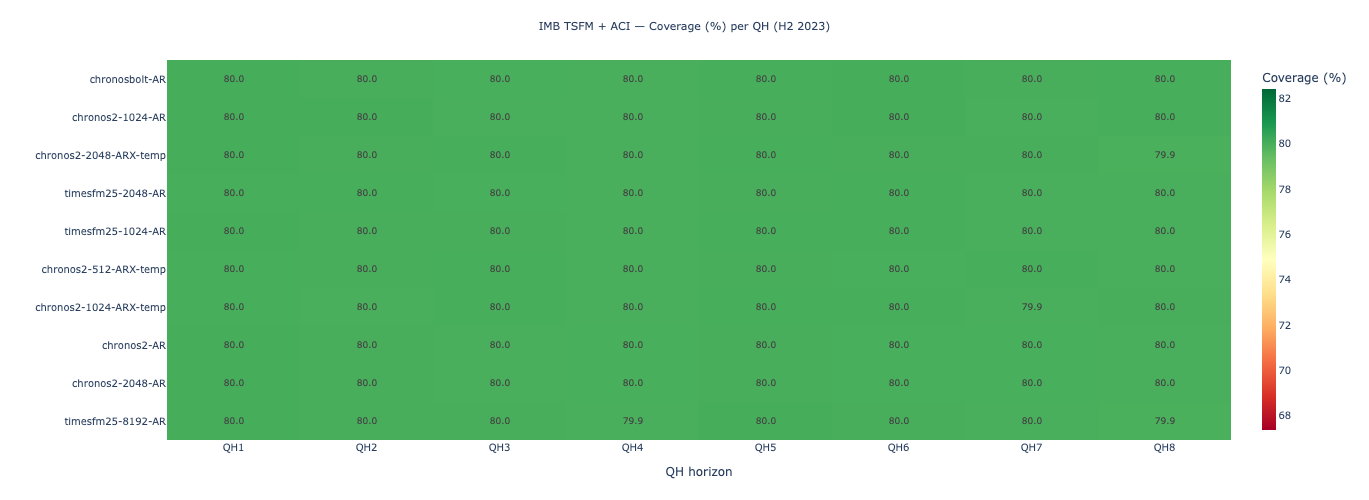

Saved → figures/imb_cp_aci_coverage_per_qh.png


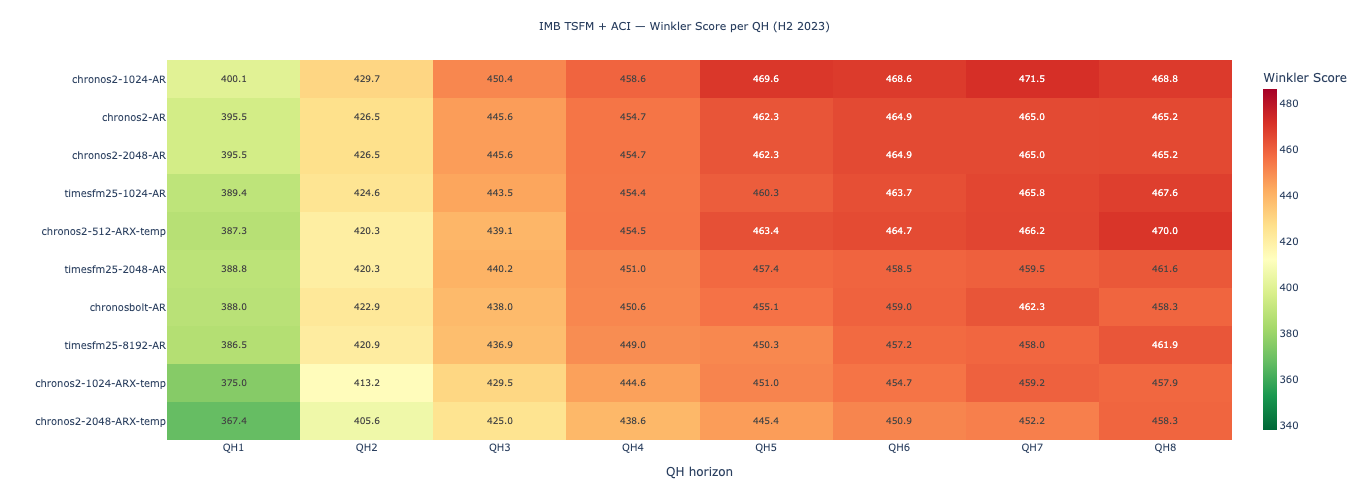

Saved → figures/imb_cp_aci_winkler_score_per_qh.png


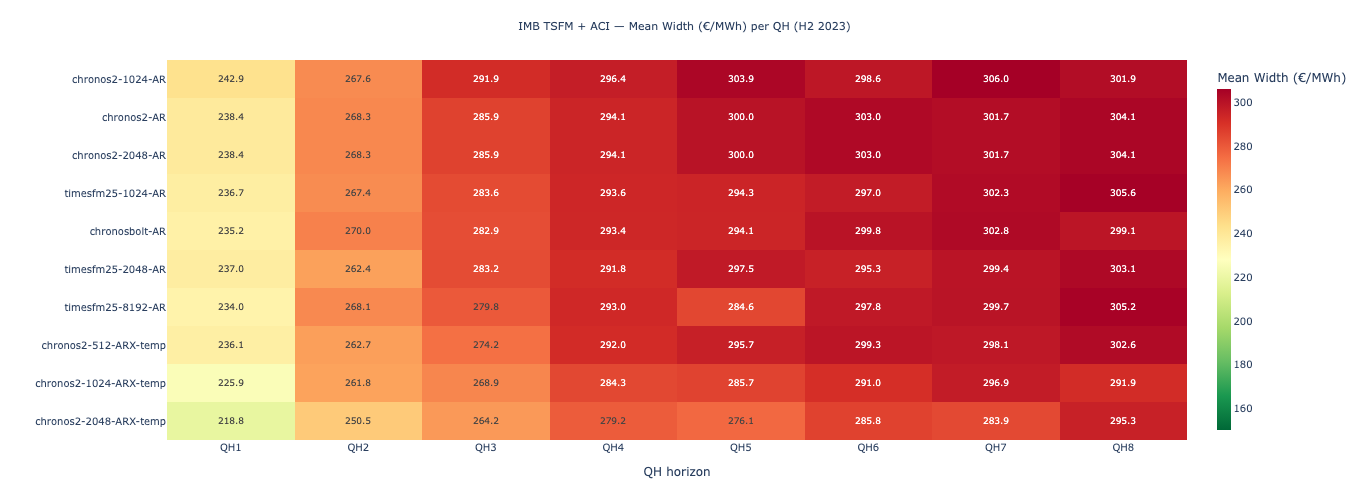

Saved → figures/imb_cp_aci_width_per_qh.png


In [17]:
imb_aci_per_qh  = pd.read_csv('forecast_interval/imb_cp_aci_per_qh.csv')
imb_aci_overall = pd.read_csv('forecast_interval/imb_cp_aci_overall.csv')

# ── IMB ACI — per-QH heatmaps (consistent z-scale) ───────────────────────────
for metric, label in zip(metrics, titles):
    zmin, zmax = SHARED_BOUNDS[metric]
    fig = plotly_qh_heatmap(
        imb_aci_per_qh, metric,
        f'IMB TSFM + ACI — {label} per QH (H2 2023)', label,
        zmin=zmin, zmax=zmax,
    )
    fname = f'figures/imb_cp_aci_{metric}_per_qh.png'
    fig.write_image(fname, width=620, height=max(300, len(_common_models)*38+120), scale=2)
    fig.show()
    print(f'Saved → {fname}')

# 3. Native QR from TSFMs

## 3.1 DAM – Native QR Evaluation (2024)

In [18]:
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('forecast_interval', exist_ok=True)
os.makedirs('figures', exist_ok=True)

# ── Load DAM summary files ────────────────────────────────────────────────────
dam_upper = pd.read_csv('dam_summary_upper.csv', parse_dates=['Date'])
dam_lower = pd.read_csv('dam_summary_lower.csv', parse_dates=['Date'])
dam_point = pd.read_csv('dam_summary_point.csv', parse_dates=['Date'])

# Upper/lower cover 2023-2024; filter to test period matching dam_summary_point (2024)
START_DAM = pd.Timestamp('2024-01-01')
END_DAM   = pd.Timestamp('2024-12-31 23:59:59')
dam_upper = dam_upper[(dam_upper['Date'] >= START_DAM) & (dam_upper['Date'] <= END_DAM)].reset_index(drop=True)
dam_lower = dam_lower[(dam_lower['Date'] >= START_DAM) & (dam_lower['Date'] <= END_DAM)].reset_index(drop=True)

# Models present in both upper and lower (drop LEAR which is empty)
dam_models = [c for c in dam_upper.columns if c != 'Date' and dam_upper[c].notna().any()]

print(f"DAM test period: {START_DAM.date()} – {END_DAM.date()}  |  N={len(dam_upper):,} hours")
print(f"Models: {dam_models}")

# ── Evaluate each model ───────────────────────────────────────────────────────
alpha = 0.2  # 80% prediction interval (0.1–0.9 quantiles)
dam_rows = []
for model in dam_models:
    upper = dam_upper[model].values
    lower = dam_lower[model].values
    y     = dam_point['price'].values

    # skip if either column is all-NaN
    mask = ~(np.isnan(upper) | np.isnan(lower) | np.isnan(y))
    if mask.sum() == 0:
        continue

    score, cov = winkler_score(y[mask], lower[mask], upper[mask], alpha=alpha)
    width = np.mean(np.abs(upper[mask] - lower[mask]))
    dam_rows.append({'model': model,
                     'coverage': round(cov * 100, 4),
                     'winkler_score': round(score, 4),
                     'width': round(width, 4),
                     'n': int(mask.sum())})

dam_results = pd.DataFrame(dam_rows).sort_values('model').reset_index(drop=True)
dam_results.to_csv('forecast_interval/dam_native_qr.csv', index=False)
print("\n=== DAM Native QR (80% PI) ===")
display(dam_results[['model', 'coverage', 'winkler_score', 'width']])

DAM test period: 2024-01-01 – 2024-12-31  |  N=8,784 hours
Models: ['timesfm25_1024_AR_neg', 'chronos2_8192_ARX_temporal', 'chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'chronos2_1024_ARX_temporal', 'timesfm25_2048_AR_neg', 'LEAR', 'chronos2_lora_tuned']

=== DAM Native QR (80% PI) ===


,model,coverage,winkler_score,width
0,LEAR,73.0874,122.9403,72.3360
1,chronos2_1024_ARX_temporal,72.4727,61.9310,33.7336
2,chronos2_2048_ARX_temporal,72.8370,60.6057,33.3089
3,chronos2_8192_ARX_temporal,75.8197,59.7332,35.1414
4,chronos2_lora_tuned,76.3206,70.2415,44.6540
5,timesfm25_1024_AR_neg,80.3393,80.2509,53.4293
6,timesfm25_2048_AR_neg,80.3620,79.8095,53.4717
7,timesfm25_8192_AR_neg,80.0888,77.1541,51.4251


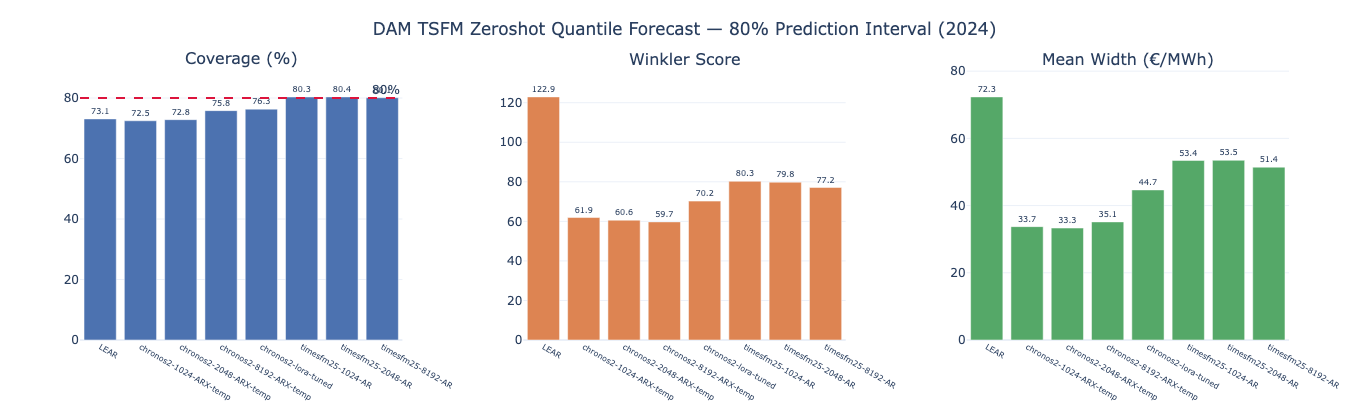

Saved → figures/dam_native_qr_metrics.png


In [19]:
NOMINAL_COV = 80.0
metrics = ['coverage', 'winkler_score', 'width']
titles  = ['Coverage (%)', 'Winkler Score', 'Mean Width (€/MWh)']
COLORS  = ['#4C72B0', '#DD8452', '#55A868']
TEMPLATE = 'plotly_white'

fig = make_subplots(rows=1, cols=3, subplot_titles=titles, horizontal_spacing=0.1)
for c, (metric, title, color) in enumerate(zip(metrics, titles, COLORS), start=1):
    lbls = dam_results['model'].str.replace('_temporal', '-temp').str.replace('_neg', '').str.replace('_', '-')
    vals = dam_results[metric]
    text = [f'{v:.1f}' for v in vals]
    fig.add_trace(go.Bar(x=lbls, y=vals, marker_color=color, text=text,
                         textposition='outside', textfont_size=8, showlegend=False),
                  row=1, col=c)
    if metric == 'coverage':
        fig.add_hline(y=NOMINAL_COV, line_dash='dash', line_color='crimson',
                      annotation_text='80%', row=1, col=c)

fig.update_layout(
    title_text='DAM TSFM Zeroshot Quantile Forecast — 80% Prediction Interval (2024)',
    title_x=0.5, template=TEMPLATE, height=420, width=1100,
    margin=dict(t=70, b=80),
)
fig.update_xaxes(tickangle=30, tickfont_size=8)
fig.write_image('figures/dam_native_qr_metrics.png', width=1100, height=420, scale=2)
fig.show()
print("Saved → figures/dam_native_qr_metrics.png")

## 3.2 IMB – Native QR Evaluation (2023-H2)

In [20]:
# ── Load IMB summary files ────────────────────────────────────────────────────
imb_upper = pd.read_csv('imb_summary_upper.csv', parse_dates=['timestamp'])
imb_lower = pd.read_csv('imb_summary_lower.csv', parse_dates=['timestamp'])
imb_point = pd.read_csv('imb_summary_point.csv', parse_dates=['timestamp'])

# Test period: H2 2023 (consistent with Phase 2 test set)
START_IMB = pd.Timestamp('2023-07-01')
END_IMB   = pd.Timestamp('2023-12-31 23:59:59')
imb_upper = imb_upper[(imb_upper['timestamp'] >= START_IMB) & (imb_upper['timestamp'] <= END_IMB)].reset_index(drop=True)
imb_lower = imb_lower[(imb_lower['timestamp'] >= START_IMB) & (imb_lower['timestamp'] <= END_IMB)].reset_index(drop=True)
imb_point = imb_point[(imb_point['timestamp'] >= START_IMB) & (imb_point['timestamp'] <= END_IMB)].reset_index(drop=True)

imb_models = [c for c in imb_upper.columns if c not in ('timestamp', 'QH') and imb_upper[c].notna().any()]

print(f"IMB test period: {START_IMB.date()} – {END_IMB.date()}  |  N={len(imb_upper):,} 15-min windows")
print(f"Models: {imb_models}")

# ── Evaluate overall and per-QH ───────────────────────────────────────────────
alpha = 0.2
imb_rows_overall = []
imb_rows_per_qh  = []

for model in imb_models:
    upper_all = imb_upper[model].values
    lower_all = imb_lower[model].values
    y_all     = imb_point['price'].values

    # overall (all QH pooled)
    mask = ~(np.isnan(upper_all) | np.isnan(lower_all) | np.isnan(y_all))
    if mask.sum() > 0:
        score, cov = winkler_score(y_all[mask], lower_all[mask], upper_all[mask], alpha=alpha)
        width = np.mean(np.abs(upper_all[mask] - lower_all[mask]))
        imb_rows_overall.append({'model': model,
                                  'coverage': round(cov * 100, 4),
                                  'winkler_score': round(score, 4),
                                  'width': round(width, 4),
                                  'n': int(mask.sum())})

    # per QH
    for qh in sorted(imb_upper['QH'].unique()):
        qh_mask = (imb_upper['QH'] == qh).values
        u = upper_all[qh_mask]
        l = lower_all[qh_mask]
        y = y_all[qh_mask]
        m = ~(np.isnan(u) | np.isnan(l) | np.isnan(y))
        if m.sum() == 0:
            continue
        s, c = winkler_score(y[m], l[m], u[m], alpha=alpha)
        w = np.mean(np.abs(u[m] - l[m]))
        imb_rows_per_qh.append({'model': model, 'QH': int(qh),
                                  'coverage': round(c * 100, 4),
                                  'winkler_score': round(s, 4),
                                  'width': round(w, 4)})

imb_results       = pd.DataFrame(imb_rows_overall).sort_values('model').reset_index(drop=True)
imb_results_per_qh = pd.DataFrame(imb_rows_per_qh).sort_values(['model', 'QH']).reset_index(drop=True)

imb_results.to_csv('forecast_interval/imb_native_qr.csv', index=False)
imb_results_per_qh.to_csv('forecast_interval/imb_native_qr_per_qh.csv', index=False)

print("\n=== IMB Native QR – Overall (80% PI) ===")
display(imb_results[['model', 'coverage', 'winkler_score', 'width']])

IMB test period: 2023-07-01 – 2023-12-31  |  N=141,276 15-min windows
Models: ['chronos2_2048_ARX_temporal', 'timesfm25_8192_AR_neg', 'chronos2_1024_AR', 'chronos2_1024_ARX_temporal', 'chronos2_lora_tuned', 'timesfm25_2048_AR_neg', 'chronos2_512_ARX_temporal', 'chronos2_2048_AR']

=== IMB Native QR – Overall (80% PI) ===


,model,coverage,winkler_score,width
0,chronos2_1024_AR,77.7450,425.3182,261.9864
1,chronos2_1024_ARX_temporal,79.2987,414.4515,260.4209
2,chronos2_2048_AR,77.3812,419.0046,258.3323
3,chronos2_2048_ARX_temporal,80.1877,409.6485,265.6350
4,chronos2_512_ARX_temporal,77.8660,425.2091,258.2165
5,chronos2_lora_tuned,78.7466,411.9293,256.9513
6,timesfm25_2048_AR_neg,77.8136,426.9947,253.7889
7,timesfm25_8192_AR_neg,77.5270,424.9031,250.4144


In [21]:
imb_finetune_results = imb_results_per_qh[imb_results_per_qh['model'] == 'chronos2_lora_tuned']

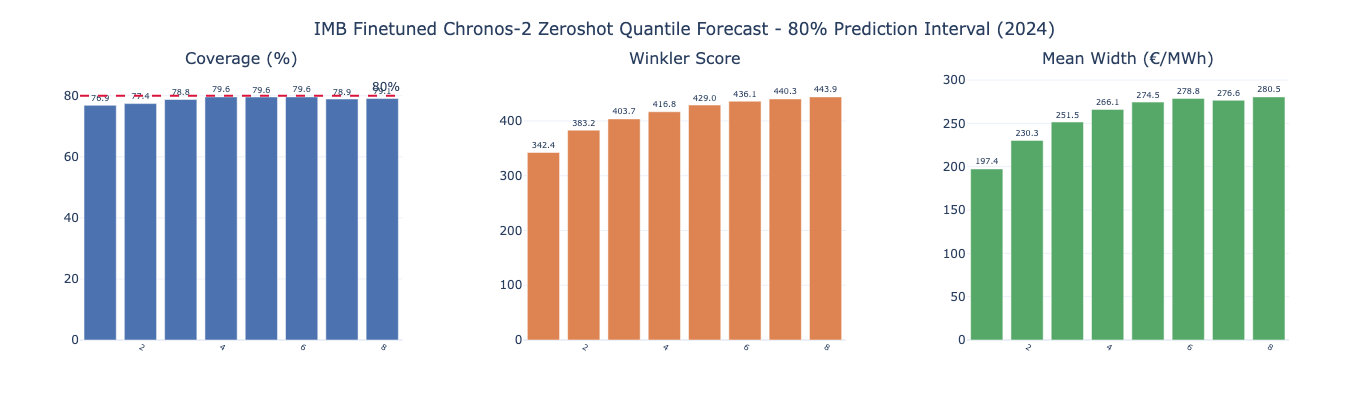

Saved → figures/imb_native_qr_metrics_finetuned.png


In [22]:
NOMINAL_COV = 80.0
metrics = ['coverage', 'winkler_score', 'width']
titles  = ['Coverage (%)', 'Winkler Score', 'Mean Width (€/MWh)']
COLORS  = ['#4C72B0', '#DD8452', '#55A868']
TEMPLATE = 'plotly_white'

fig = make_subplots(rows=1, cols=3, subplot_titles=titles, horizontal_spacing=0.1)

for c, (metric, title, color) in enumerate(zip(metrics, titles, COLORS), start=1):
    lbls = imb_finetune_results['QH']#.str.replace('_temporal', '-temp').str.replace('_neg', '').str.replace('_', '-')
    vals = imb_finetune_results[metric]
    text = [f'{v:.1f}' for v in vals]
    fig.add_trace(go.Bar(x=lbls, y=vals, marker_color=color, text=text,
                         textposition='outside', textfont_size=8, showlegend=False),
                  row=1, col=c)
    if metric == 'coverage':
        fig.add_hline(y=NOMINAL_COV, line_dash='dash', line_color='crimson',
                      annotation_text='80%', row=1, col=c)

fig.update_layout(
    title_text='IMB Finetuned Chronos-2 Zeroshot Quantile Forecast - 80% Prediction Interval (2024)',
    title_x=0.5, template=TEMPLATE, height=420, width=1100,
    margin=dict(t=70, b=80),
)
fig.update_xaxes(tickangle=30, tickfont_size=8)
fig.write_image('figures/imb_native_qr_metrics_finetuned.png', width=1100, height=420, scale=2)
fig.show()
print("Saved → figures/imb_native_qr_metrics_finetuned.png")

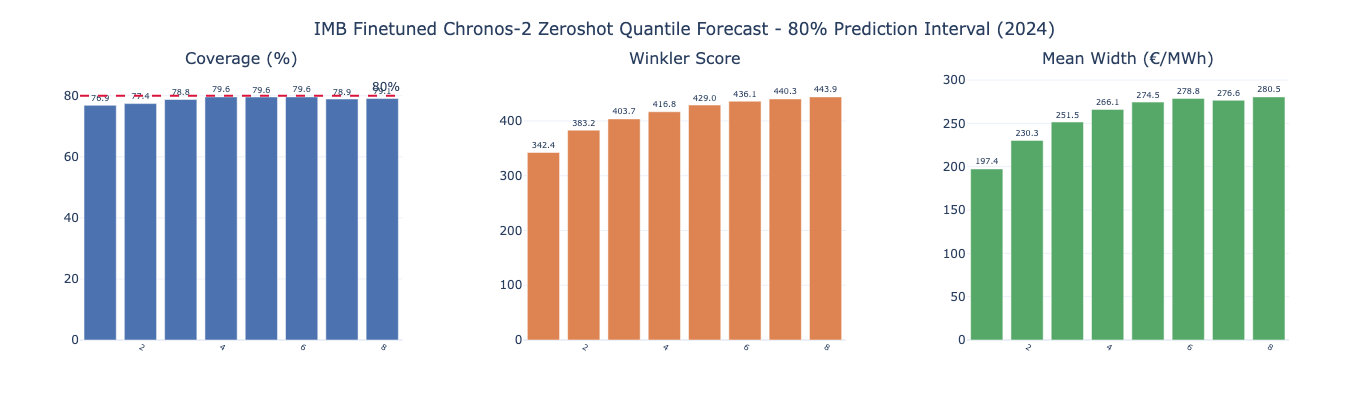

In [23]:
fig.show()

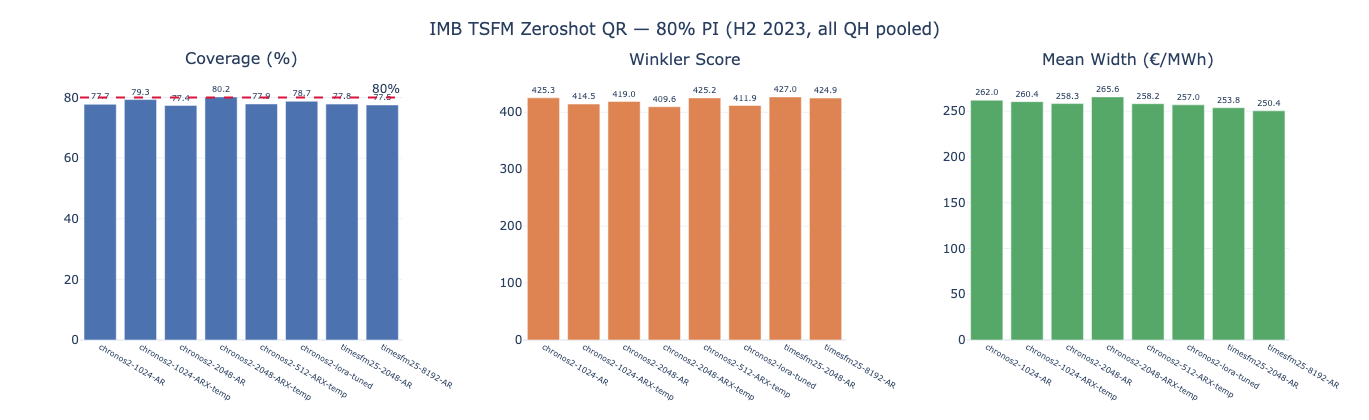

Saved → figures/imb_native_qr_metrics.png


In [24]:
COLORS   = ['#4C72B0', '#DD8452', '#55A868']
TEMPLATE = 'plotly_white'

# Overall bar chart only (per-QH heatmaps skipped)
fig = make_subplots(rows=1, cols=3, subplot_titles=titles, horizontal_spacing=0.1)
for c, (metric, title, color) in enumerate(zip(metrics, titles, COLORS), start=1):
    lbls = imb_results['model'].str.replace('_temporal', '-temp').str.replace('_neg', '').str.replace('_', '-')
    vals = imb_results[metric]
    text = [f'{v:.1f}' for v in vals]
    fig.add_trace(go.Bar(x=lbls, y=vals, marker_color=color, text=text,
                         textposition='outside', textfont_size=8, showlegend=False),
                  row=1, col=c)
    if metric == 'coverage':
        fig.add_hline(y=NOMINAL_COV, line_dash='dash', line_color='crimson',
                      annotation_text='80%', row=1, col=c)

fig.update_layout(
    title_text='IMB TSFM Zeroshot QR — 80% PI (H2 2023, all QH pooled)',
    title_x=0.5, template=TEMPLATE, height=420, width=1200,
    margin=dict(t=70, b=80),
)
fig.update_xaxes(tickangle=30, tickfont_size=8)
fig.write_image('figures/imb_native_qr_metrics.png', width=1200, height=420, scale=2)
fig.show()
print("Saved → figures/imb_native_qr_metrics.png")

In [30]:
ref_order[winkler_score]

KeyError: <function winkler_score at 0x117cc8ea0>

In [31]:
ref_order = {metric: _pivot(imb_results_per_qh, metric).index.tolist()
             for metric in metrics}

In [36]:
ref_order = {metric: sorted(_pivot(imb_results_per_qh, metric).index.tolist(), reverse=True)
             for metric in metrics}

In [39]:
order = ['timesfm25-2048-AR', 'timesfm25-8192-AR',  'chronos2-1024-AR','chronos2-2048-AR', 'chronos2-512-ARX-temp','chronos2-1024-ARX-temp','chronos2-2048-ARX-temp',]

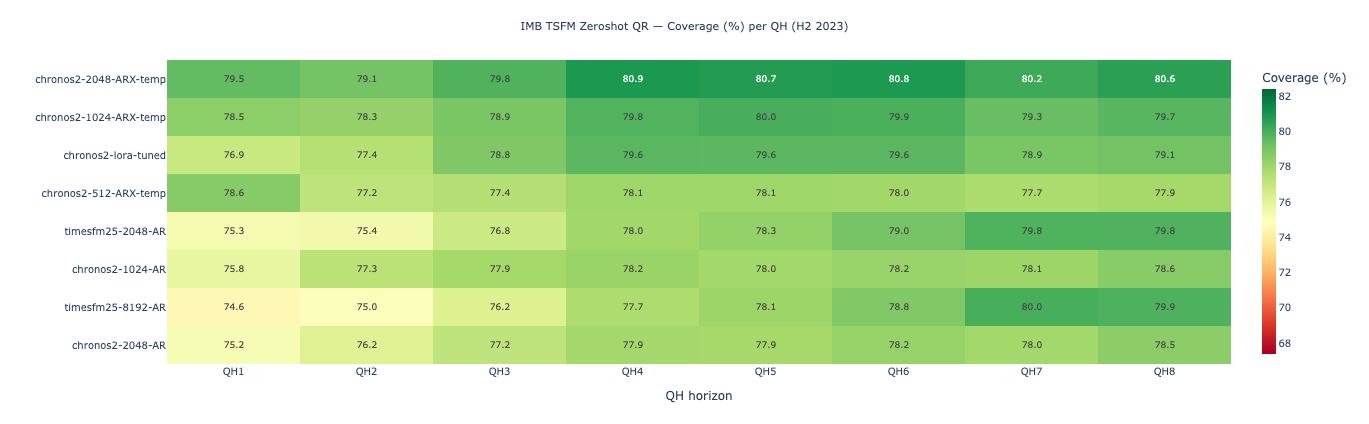

Saved → figures/imb_native_qr_coverage_per_qh.png


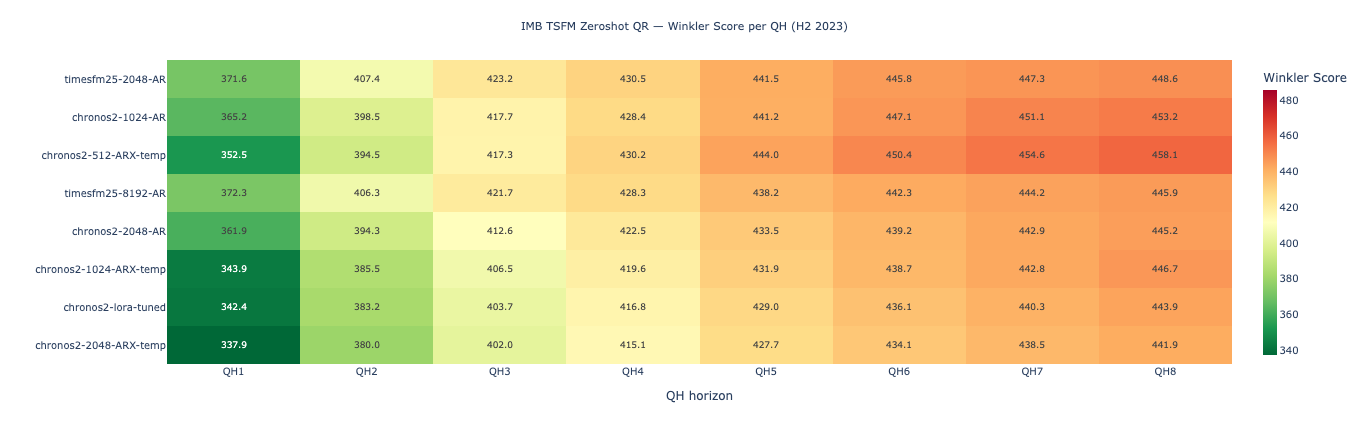

Saved → figures/imb_native_qr_winkler_score_per_qh.png


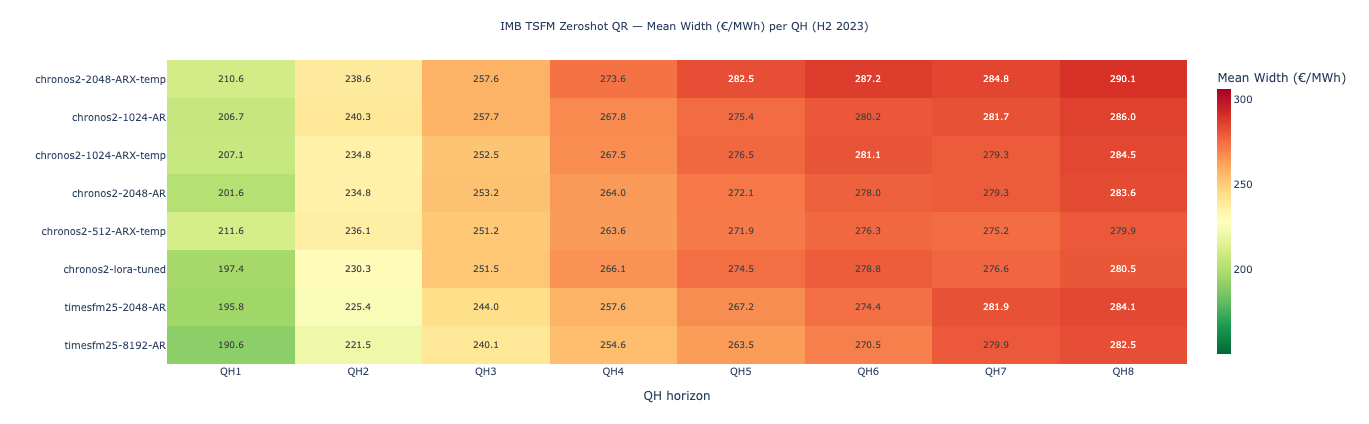

Saved → figures/imb_native_qr_width_per_qh.png


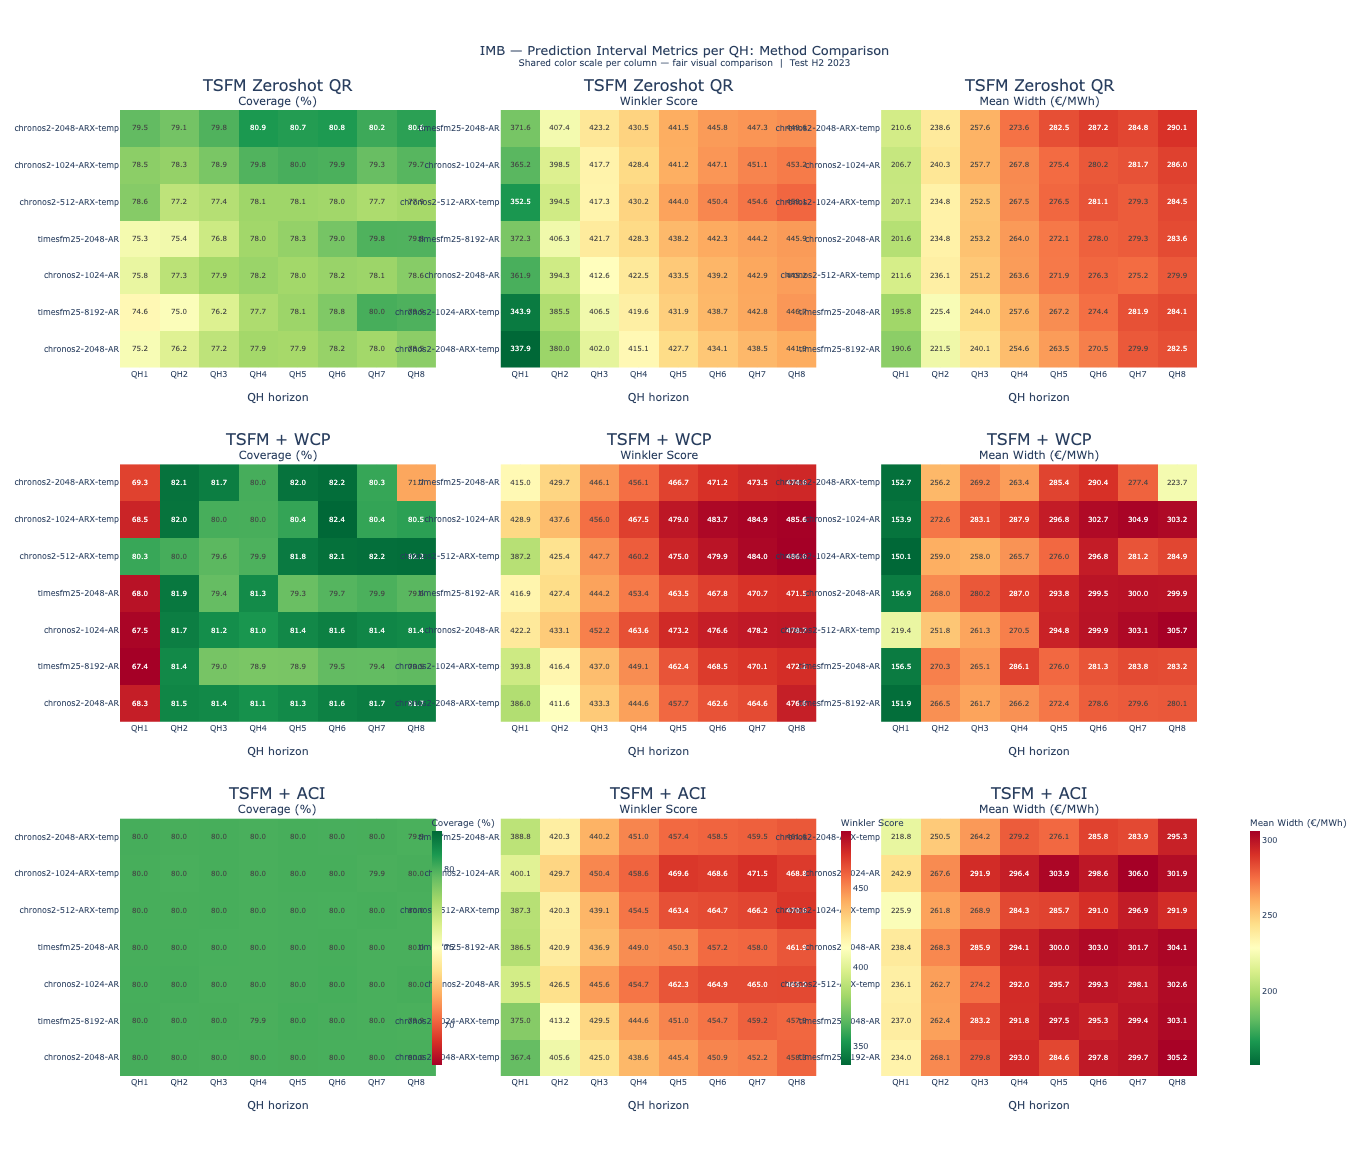

Saved → figures/imb_heatmap_comparison_perqh.png


In [25]:
imb_results_per_qh = pd.read_csv('forecast_interval/imb_native_qr_per_qh.csv')

# ── IMB Zeroshot QR — per-QH heatmaps (consistent z-scale) ──────────────────
for metric, label in zip(metrics, titles):
    zmin, zmax = SHARED_BOUNDS[metric]
    fig = plotly_qh_heatmap(
        imb_results_per_qh, metric,
        f'IMB TSFM Zeroshot QR — {label} per QH (H2 2023)', label,
        zmin=zmin, zmax=zmax,
    )
    fname = f'figures/imb_native_qr_{metric}_per_qh.png'
    fig.write_image(fname, width=620, height=max(300, len(_common_models)*38+120), scale=2)
    fig.show()
    print(f'Saved → {fname}')

# ══════════════════════════════════════════════════════════════════════════════
# Combined 3 × 3 comparison figure: rows = method, cols = metric
# Each column shares the same color scale → fair visual comparison
# ══════════════════════════════════════════════════════════════════════════════
METHOD_DFS = [
    ('TSFM Zeroshot QR', imb_results_per_qh),
    ('TSFM + WCP',       imb_wcp_per_qh),
    ('TSFM + ACI',       imb_aci_per_qh),
]
COLORSCALES = {'coverage': 'RdYlGn', 'winkler_score': 'RdYlGn_r', 'width': 'RdYlGn_r'}

n_rows   = len(METHOD_DFS)
n_cols   = len(metrics)
n_models = len(_common_models)
row_h    = max(280, n_models * 36 + 100)

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=[f'{m_name}<br><sup>{title}</sup>'
                    for m_name, _ in METHOD_DFS
                    for title in titles],
    horizontal_spacing=0.06,
    vertical_spacing=0.10,
)

# Precompute sorted model order per metric (use Zeroshot as reference)
def _pivot(df, metric):
    df2 = df[df['model'].isin(_common_models)].copy()
    df2['lbl'] = (df2['model']
                  .str.replace('_temporal', '', regex=False)
                  .str.replace('_neg', '', regex=False)
                  .str.replace('_', '-', regex=False))
    pv = df2.pivot_table(index='lbl', columns='QH', values=metric, aggfunc='mean')
    return pv.loc[pv.mean(axis=1).sort_values().index]

ref_order = {metric: sorted(_pivot(imb_results_per_qh, metric).index.tolist())
             for metric in metrics}

for r, (m_name, df) in enumerate(METHOD_DFS, start=1):
    for c, (metric, label) in enumerate(zip(metrics, titles), start=1):
        pv    = _pivot(df, metric)
        pv    = pv.reindex(ref_order[metric])          # same row order across methods
        zmin, zmax = SHARED_BOUNDS[metric]
        text_v = [[f'{v:.1f}' for v in row] for row in pv.values]

        # Only show colorbar on last row for each column (avoid 9 colorbars)
        show_cb = (r == n_rows)
        cb_x = 0.28 + (c - 1) * 0.38          # rough x positions for 3 colorbars

        fig.add_trace(
            go.Heatmap(
                z=pv.values,
                x=[f'QH{q}' for q in pv.columns],
                y=pv.index.tolist(),
                colorscale=COLORSCALES[metric],
                zmin=zmin, zmax=zmax,
                text=text_v, texttemplate='%{text}',
                textfont_size=7,
                showscale=show_cb,
                colorbar=dict(
                    title=dict(text=label, font=dict(size=9)),
                    thickness=10, len=0.28,
                    x=cb_x, y=0.14,           # anchor at bottom row
                    tickfont=dict(size=8),
                ) if show_cb else None,
            ),
            row=r, col=c,
        )

fig.update_layout(
    title_text='IMB — Prediction Interval Metrics per QH: Method Comparison<br>'
               '<sup>Shared color scale per column — fair visual comparison  |  Test H2 2023</sup>',
    title_x=0.5, title_font_size=13,
    template='plotly_white',
    height=row_h * n_rows + 120,
    width=1300,
    margin=dict(l=120, r=60, t=110, b=100),
    font_size=9,
)
fig.update_xaxes(title_text='QH horizon', tickfont_size=8)
fig.update_yaxes(tickfont_size=8)

out = 'figures/imb_heatmap_comparison_perqh.png'
fig.write_image(out, width=1300, height=row_h * n_rows + 120, scale=2)
fig.write_html(out.replace('.png', '.html'))
fig.show()
print(f'Saved → {out}')

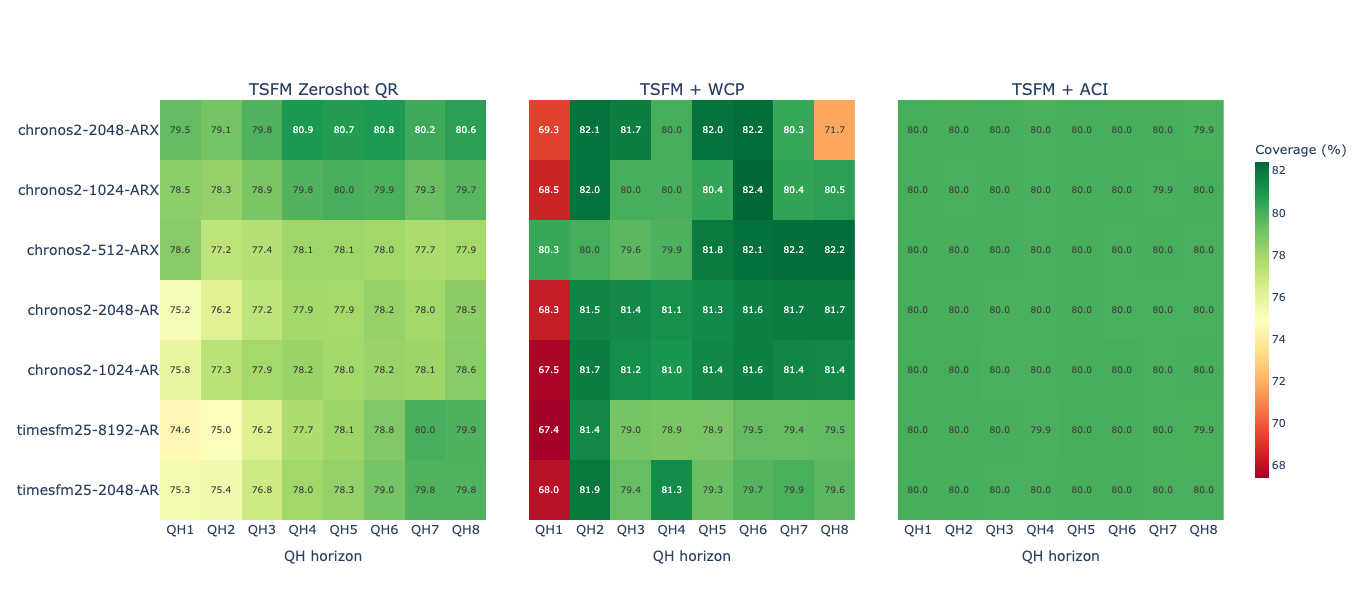

Saved → figures/imb_coverage_comparison_perqh.png


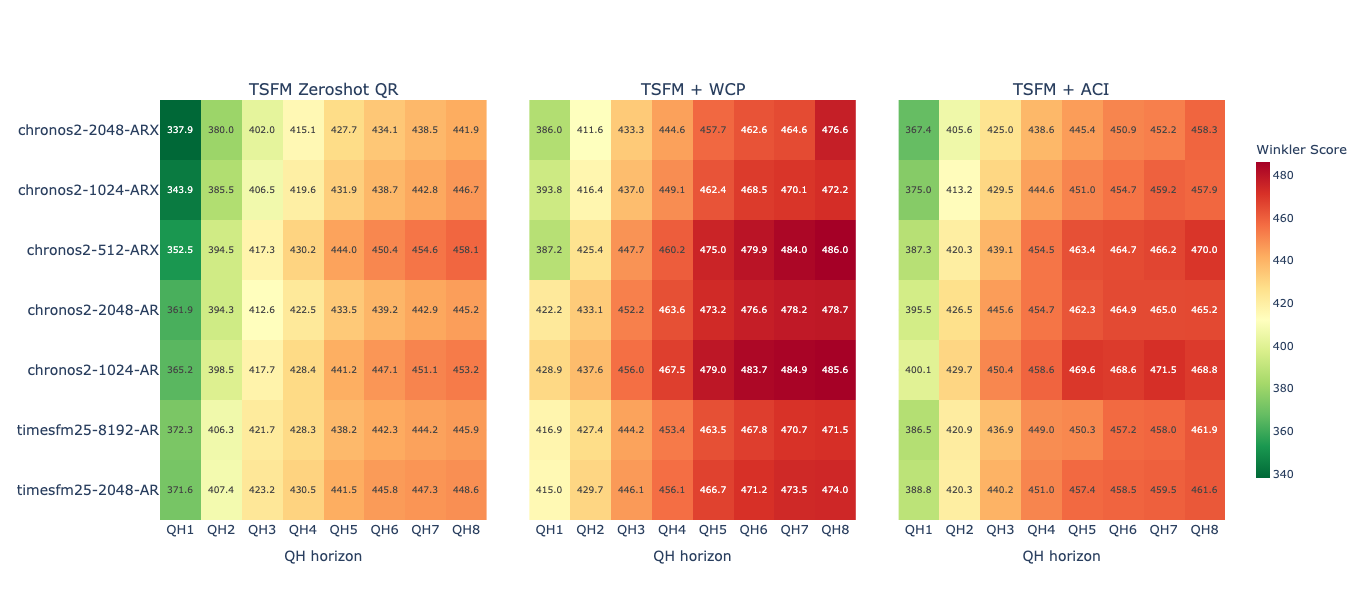

Saved → figures/imb_winkler_comparison_perqh.png


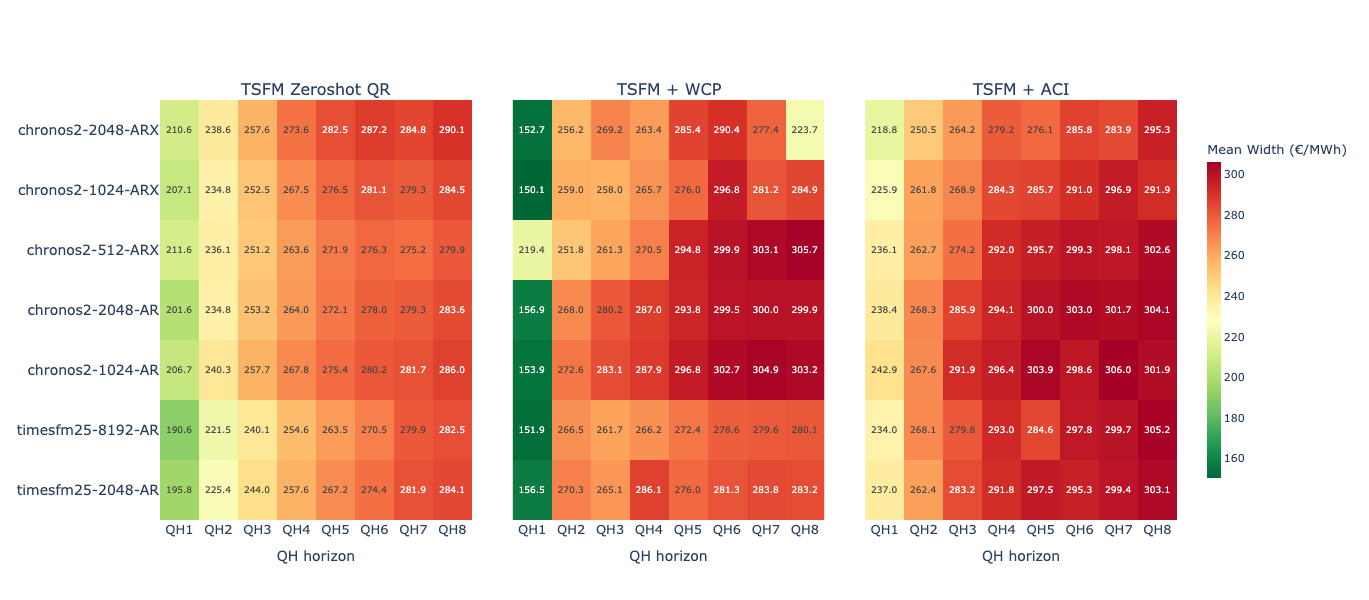

Saved → figures/imb_width_comparison_perqh.png


In [44]:
# ══════════════════════════════════════════════════════════════════════════════
# Per-metric comparison: 3 methods (Zeroshot / WCP / ACI) side-by-side
# One figure per metric, shared color scale across all three panels
# ══════════════════════════════════════════════════════════════════════════════
METRIC_FNAMES = {
    'coverage':      'figures/imb_coverage_comparison_perqh',
    'winkler_score': 'figures/imb_winkler_comparison_perqh',
    'width':         'figures/imb_width_comparison_perqh',
}
COLORSCALES = {'coverage': 'RdYlGn', 'winkler_score': 'RdYlGn_r', 'width': 'RdYlGn_r'}
# ══════════════════════════════════════════════════════════════════════════════
METHOD_DFS = [
    ('TSFM Zeroshot QR', imb_results_per_qh),
    ('TSFM + WCP',       imb_wcp_per_qh),
    ('TSFM + ACI',       imb_aci_per_qh),
]

n_models = len(_common_models)
row_h    = max(700, n_models * 40 + 140)
row_h = 600
for metric, label in zip(metrics, titles):
    zmin, zmax = SHARED_BOUNDS[metric]
    cs         = COLORSCALES[metric]

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=[m_name for m_name, _ in METHOD_DFS],
        horizontal_spacing=0.04,
    )

    for c, (m_name, df) in enumerate(METHOD_DFS, start=1):
        pv     = _pivot(df, metric).reindex(order)
        text_v = [[f'{v:.1f}' for v in row] for row in pv.values]
        show_cb = (c == 3)           # single colorbar on the right panel

        fig.add_trace(
            go.Heatmap(
                z=pv.values,
                x=[f'QH{q}' for q in pv.columns],
                y=[x.replace('-temp','') for x in pv.index.tolist()],
                colorscale=cs,
                zmin=zmin, zmax=zmax,
                text=text_v, texttemplate='%{text}',
                textfont_size=9,
                showscale=show_cb,
                colorbar=dict(
                    title=dict(text=label, font=dict(size=13)),
                    thickness=14, len=0.85,
                    tickfont=dict(size=11),
                ) if show_cb else None,
            ),
            row=1, col=c,
        )

    # model labels only on leftmost panel
    fig.update_yaxes(showticklabels=False, row=1, col=2)
    fig.update_yaxes(showticklabels=False, row=1, col=3)
    fig.update_yaxes(showticklabels=True, row=1, col=1, tickfont_size=14)
    fig.update_xaxes(title_text='QH horizon', tickfont_size=13, title_font_size=14)

    fig.update_layout(
        # title_text=(f'IMB - {label} per QH: Method Comparison<br>'),
        
        title_x=0.5, title_font_size=14,
        template='plotly_white',
        
        height=row_h, width=1500,
        margin=dict(l=160, r=90, t=100, b=80),
        font_size=9,
    )

    base = METRIC_FNAMES[metric]
    fig.write_image(base + '.png', width=1500, height=row_h, scale=2)
    # fig.write_html(base + '.html')
    fig.show()
    print(f'Saved → {base}.png')